In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from sklearn.metrics import classification_report

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
TEST_YEAR = '2010'

train_file = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\GR_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\CMacedonia\GR_CMacedonia_WNV_Dataset_GRID_OP_2010.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(52992, 91)


In [2]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [3]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL52,EL524,εδεσσας,2010,1,21.76334,40.79806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.075806,9.402258,5.725714,14.073226,19.750667,1.757742,-3.311290,-2.010000,2.497097,6.460667,5.416774,3.045484,1.857857,8.285161,13.105667,-0.89,15.65,9.033419,78.548186,135.838324,257.839473,105.339787,14.000000,22.500000,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,2,3,2
1,1,EL52,EL524,εδεσσας,2010,1,21.76334,40.81603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.371290,2.743548,2.327143,13.366129,20.487333,0.675806,-3.806774,-2.923571,1.590645,4.859333,5.023548,-0.531613,-0.298214,7.478387,12.673333,-1.69,15.25,9.110539,79.223056,141.628645,264.194706,103.766240,13.166667,22.166667,46.180556,790.952629,39.0,-9.0,48.0,5.833333,22.000000,22.833333,3.500000,1665.0,282.0,39.0,59.298922,752.0,208.0,313.0,601.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,2,3,2
2,2,EL52,EL524,εδεσσας,2010,1,21.76334,40.83400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.606129,4.301613,-1.627857,10.604194,21.157333,-0.327419,-4.568065,-3.911429,0.762258,3.151333,3.639355,-0.133226,-2.769643,5.683226,12.154333,-2.11,13.95,9.110539,79.223056,141.628645,264.194706,103.766240,11.583333,22.166667,48.188406,754.632160,37.0,-9.0,46.0,5.000000,20.166667,21.000000,2.166667,1665.0,282.0,39.0,59.298922,752.0,208.0,313.0,409.0,31,36,30,12,12,3,5,8,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,2,3,2
3,3,EL52,EL524,εδεσσας,2010,1,21.76334,40.85196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.685484,-6.484194,-4.350000,10.302632,17.369333,0.768065,-1.443548,0.224545,0.609355,3.042667,3.226774,-3.963871,-2.062727,5.455993,10.206000,-2.33,12.13,9.110539,79.223056,141.628645,264.194706,103.766240,10.333333,20.833333,49.603175,695.548617,34.0,-8.0,42.0,5.000000,17.833333,18.333333,1.000000,1665.0,282.0,39.0,59.298922,752.0,208.0,313.0,409.0,31,36,30,12,12,3,5,8,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,2,3,2
4,4,EL52,EL524,εδεσσας,2010,1,21.78676,40.79806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.691290,7.888710,5.421429,12.431935,16.202667,4.182258,2.904194,1.812857,3.929355,7.994667,6.936774,5.396452,3.617143,8.180645,12.098667,2.17,13.79,9.033419,78.548186,135.838324,257.839473,105.339787,13.583333,14.833333,41.203704,782.139645,33.0,-3.0,36.0,6.666667,22.833333,23.666667,4.500000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,392.0,3,3,3,17,0,0,0,0,0.000000,1220.287752,0,0.051487,528.278124,17

In [4]:
len(data_train.cell_code.unique())

4260

In [5]:
len(data_test.cell_number.unique())

4416

In [6]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [7]:
data_train.cases.sum()

1364

In [8]:
# data_test.cases.sum()

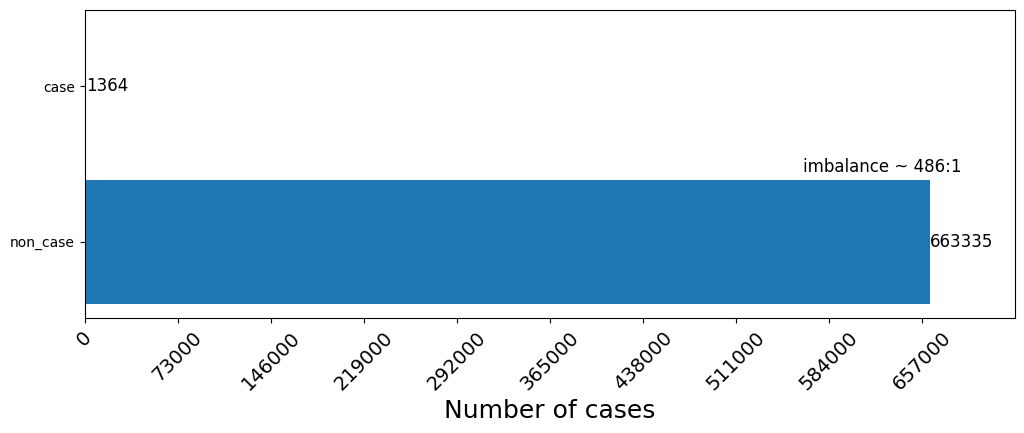

In [9]:
plot_imbalance(data_train, target_column='cases')

In [10]:
# plot_imbalance(data_test, target_column='cases')

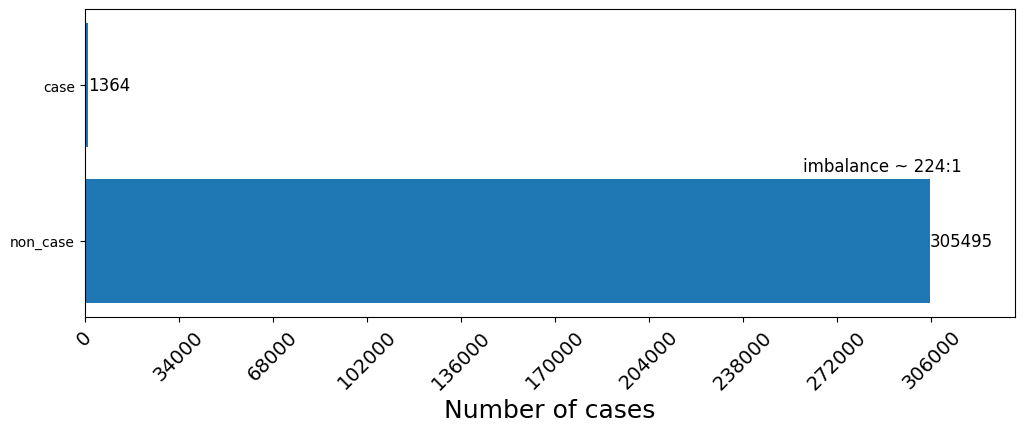

In [11]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [12]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

# plot_imbalance(data_test, target_column='cases')

In [13]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

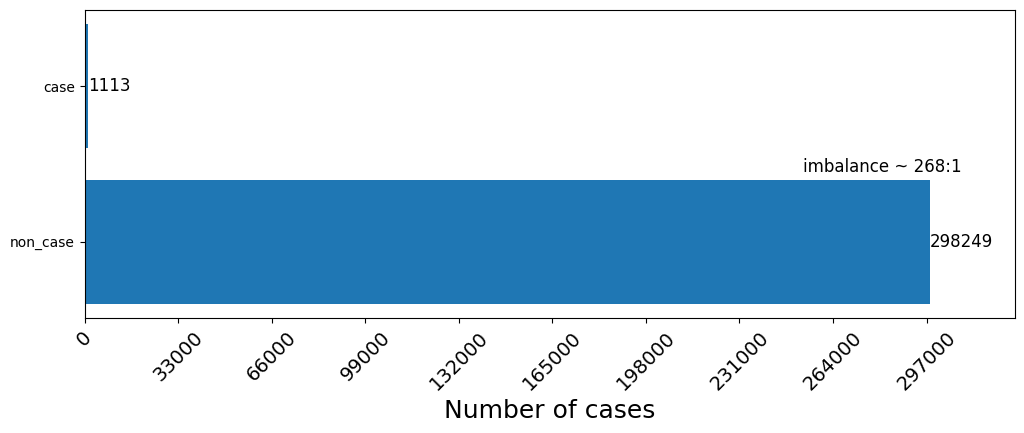

In [14]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [15]:
# hot_cells = dataset[dataset['cases']>0].cell_code.unique().tolist()

# dataset = dataset.query("cell_code in @hot_cells")

# dataset.reset_index(drop=True, inplace=True)

# plot_imbalance(dataset, target_column='cases')

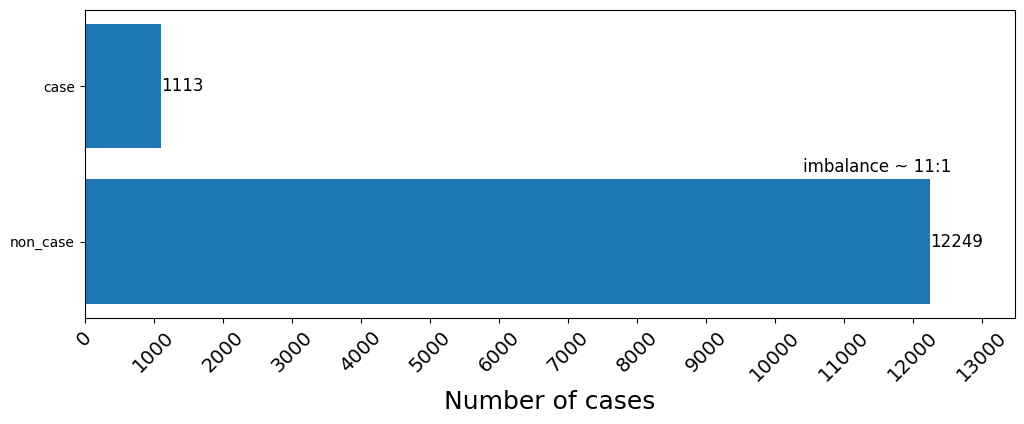

In [16]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [17]:
data_train.shape

(13262, 94)

In [18]:
data_train.cases.sum()

1113

In [19]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,734,11,745,66.73%
1,2011,1055,100,1155,10.55%
2,2012,989,157,1146,6.30%
3,2013,1081,85,1166,12.72%
4,2014,1006,15,1021,67.07%
5,2015,1028,0,1028,inf%
6,2016,1073,0,1073,inf%
7,2017,993,42,1035,23.64%
8,2018,1038,296,1334,3.51%
9,2019,1082,218,1300,4.96%


In [20]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [21]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 11.01
Weight: 11.01


In [22]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [23]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL52,EL524,εδεσσας,2010,5,21.76334,40.79806,0.450848,0.010165,-0.402933,-0.010165,0.444931,0.008081,-0.403259,-0.008081,0.050565,0.066633,0.025007,0.066633,19.750667,9.402258,5.725714,14.073226,19.750667,6.460667,-3.311290,-2.010000,2.497097,6.460667,13.105667,3.045484,1.857857,8.285161,13.105667,-1.49,24.89,3.213582,6.752244,76.330291,96.407450,727.911790,14.000000,22.500000,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,2,3,2,0.500000,-0.866025
1,1,EL52,EL524,εδεσσας,2010,5,21.76334,40.81603,0.393674,-0.045444,-0.431146,0.045444,0.385745,-0.053766,-0.434490,0.053766,0.036527,0.042990,0.019888,0.042990,20.487333,2.743548,2.327143,13.366129,20.487333,4.859333,-3.806774,-2.923571,1.590645,4.859333,12.673333,-0.531613,-0.298214,7.478387,12.673333,2.15,23.63,3.267990,7.299363,60.052013,98.039695,732.316077,13.166667,22.166667,46.180556,790.952629,39.0,-9.0,48.0,5.833333,22.000000,22.833333,3.500000,1665.0,282.0,39.0,59.298922,752.0,208.0,313.0,601.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,2,3,2,0.500000,-0.866025
2,2,EL52,EL524,εδεσσας,2010,5,21.76334,40.83400,0.305356,0.011563,-0.331208,-0.011563,0.388513,-0.010830,-0.409096,0.010830,0.067663,0.086512,0.061239,0.086512,21.157333,4.301613,-1.627857,10.604194,21.157333,3.151333,-4.568065,-3.911429,0.762258,3.151333,12.154333,-0.133226,-2.769643,5.683226,12.154333,0.41,23.11,3.267990,7.299363,60.052013,98.039695,732.316077,11.583333,22.166667,48.188406,754.632160,37.0,-9.0,46.0,5.000000,20.166667,21.000000,2.166667,1665.0,282.0,39.0,59.298922,752.0,208.0,313.0,409.0,31,36,30,12,12,3,5,8,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,2,3,2,0.500000,-0.866025
3,3,EL52,EL524,εδεσσας,2010,5,21.76334,40.85196,0.349514,-0.116290,-0.501343,0.116290,0.355522,-0.080120,-0.462221,0.080120,0.009932,0.022985,0.020145,0.022985,17.369333,-6.484194,-4.350000,10.302632,17.369333,3.042667,-1.443548,0.224545,0.609355,3.042667,10.206000,-3.963871,-2.062727,5.455993,10.206000,-0.07,20.67,3.267990,7.299363,60.052013,98.039695,732.316077,10.333333,20.833333,49.603175,695.548617,34.0,-8.0,42.0,5.000000,17.833333,18.333333,1.000000,1665.0,282.0,39.0,59.298922,752.0,208.0,313.0,409.0,31,36,30,12,12,3,5,8,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,2,3,2,0.500000,-0.866025
4,4,EL52,EL524,εδεσσας,2010,5,21.78676,40.79806,0.189439,0.224673,0.223310,-0.224673,0.179148,0.284961,0.200370,-0.284961,0.226019,0.187686,0.433852,0.187686,16

### Results 2010 ###

In [25]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_may['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jun['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jul['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_aug['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_sep['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_oct['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [31]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1309,1309,EL52,EL522,χαλκηδονος,2010,5,22.51286,40.79806,0.089369
1360,1360,EL52,EL521,αλεξανδρειας,2010,5,22.53628,40.56450,0.065057
1820,1820,EL52,EL522,ωραιοκαστρου,2010,5,22.81735,40.69026,0.050935
1294,1294,EL52,EL525,πυδνας κολινδρου,2010,5,22.51286,40.52856,0.047395
1859,1859,EL52,EL522,δελτα,2010,5,22.84078,40.69026,0.041932


In [32]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1820,1820,EL52,EL522,ωραιοκαστρου,2010,6,22.81735,40.69026,0.206719
1430,1430,EL52,EL522,χαλκηδονος,2010,6,22.55970,40.81603,0.179999
1980,1980,EL52,EL522,κορδελιου ευοσμου,2010,6,22.91104,40.67230,0.158151
1309,1309,EL52,EL522,χαλκηδονος,2010,6,22.51286,40.79806,0.139090
1360,1360,EL52,EL521,αλεξανδρειας,2010,6,22.53628,40.56450,0.125938


In [33]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1897,1897,EL52,EL522,δελτα,2010,7,22.86420,40.69026,0.867934
947,947,EL52,EL524,πελλας,2010,7,22.37232,40.79806,0.862847
733,733,EL52,EL524,πελλας,2010,7,22.27863,40.76213,0.858469
2069,2069,EL52,EL522,παυλου μελα,2010,7,22.95789,40.69026,0.857339
777,777,EL52,EL521,αλεξανδρειας,2010,7,22.30206,40.60043,0.846768


In [34]:
results_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
733,733,EL52,EL524,πελλας,2010,8,22.27863,40.76213,0.944590
1356,1356,EL52,EL525,πυδνας κολινδρου,2010,8,22.53628,40.49263,0.932857
1210,1210,EL52,EL525,διου ολυμπου,2010,8,22.48944,40.15126,0.932745
1820,1820,EL52,EL522,ωραιοκαστρου,2010,8,22.81735,40.69026,0.930087
1527,1527,EL52,EL523,παιονιας,2010,8,22.60655,41.01366,0.929071


In [35]:
results_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
504,504,EL52,EL521,βεροιας,2010,9,22.18494,40.56450,0.934876
1820,1820,EL52,EL522,ωραιοκαστρου,2010,9,22.81735,40.69026,0.923359
2112,2112,EL52,EL522,θερμης,2010,9,22.98131,40.51060,0.919617
1430,1430,EL52,EL522,χαλκηδονος,2010,9,22.55970,40.81603,0.918901
733,733,EL52,EL524,πελλας,2010,9,22.27863,40.76213,0.916311


In [36]:
results_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1417,1417,EL52,EL521,αλεξανδρειας,2010,10,22.55970,40.58246,0.478076
1360,1360,EL52,EL521,αλεξανδρειας,2010,10,22.53628,40.56450,0.467357
1451,1451,EL52,EL525,κατερινης,2010,10,22.58313,40.31296,0.332672
504,504,EL52,EL521,βεροιας,2010,10,22.18494,40.56450,0.326591
2023,2023,EL52,EL522,αμπελοκηπων μενεμενης,2010,10,22.93447,40.65433,0.315891


In [37]:
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"
cm_grid = gpd.read_file(r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\CMacedonia\GR_CMacedonia_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')

In [38]:
cm_grid.head()

,cell_numbe,NUTS2_ID,x,y,geometry
0,0,EL52,21.76334,40.79806,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,EL52,21.76334,40.81603,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,EL52,21.76334,40.83400,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,EL52,21.76334,40.85196,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,EL52,21.78676,40.79806,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [39]:
greece_nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [40]:
greece_lau1.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [41]:
cm_grid = cm_grid.to_crs(epsg=4326)
cm_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
cm_grid = cm_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {cm_grid.crs}')

greece_index CRS: EPSG:4326


In [42]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == 'EL52']
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts2 CRS: EPSG:4326


In [43]:
greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME'], inplace=True)

wrong_list = ['Φλώρινας' ,'Αμυνταίου', 'Εορδαίας', 'Κοζάνης', 'Σερβίων - Βελβεντού', 'Ελασσόνας', 'Τεμπών', 'Κάτω Νευροκοπίου',
 'Προσοτσάνης', 'Δοξάτου', 'Παγγαίου', 'Άθως']

greece_lau1 = greece_lau1[~greece_lau1['NAME'].isin(wrong_list)].copy()
greece_lau1.reset_index(drop = True, inplace = True)

In [44]:
cm_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [45]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [47]:
greece_lau1.head()

,NAME,geometry
0,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
1,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
2,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
3,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."
4,Αμφίπολης,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."


In [48]:
results_may = pd.merge(results_may, cm_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')

results_jun = pd.merge(results_jun, cm_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')

results_jul = pd.merge(results_jul, cm_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')

results_aug = pd.merge(results_aug, cm_grid, on='cell_number', how='left')
results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')

results_sep = pd.merge(results_sep, cm_grid, on='cell_number', how='left')
results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')

results_oct = pd.merge(results_oct, cm_grid, on='cell_number', how='left')
results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')

In [49]:
float_column = 'score'
geometry_column = 'geometry'
cmap = 'coolwarm'  # Choose your preferred colormap
norm = Normalize(vmin=0, vmax=1)
mapper = ScalarMappable(norm=norm, cmap=cmap)

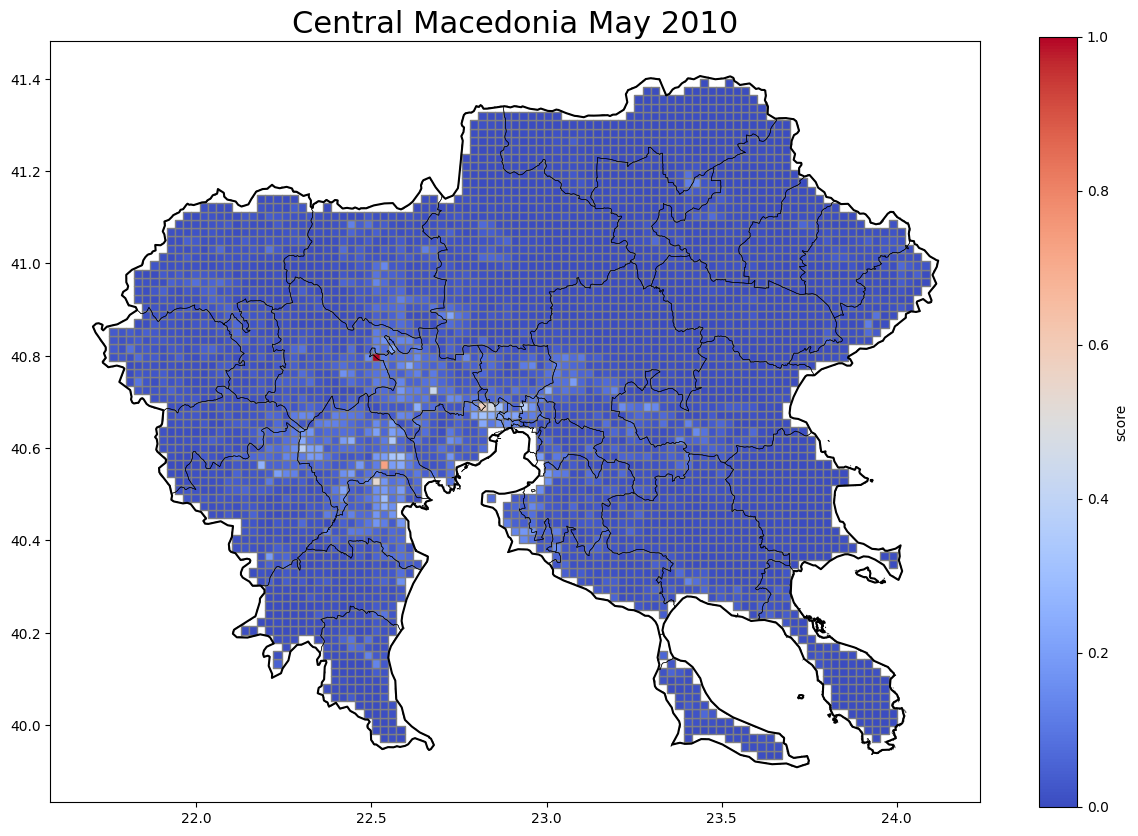

In [50]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column

results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title(f'Central Macedonia May {TEST_YEAR}', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

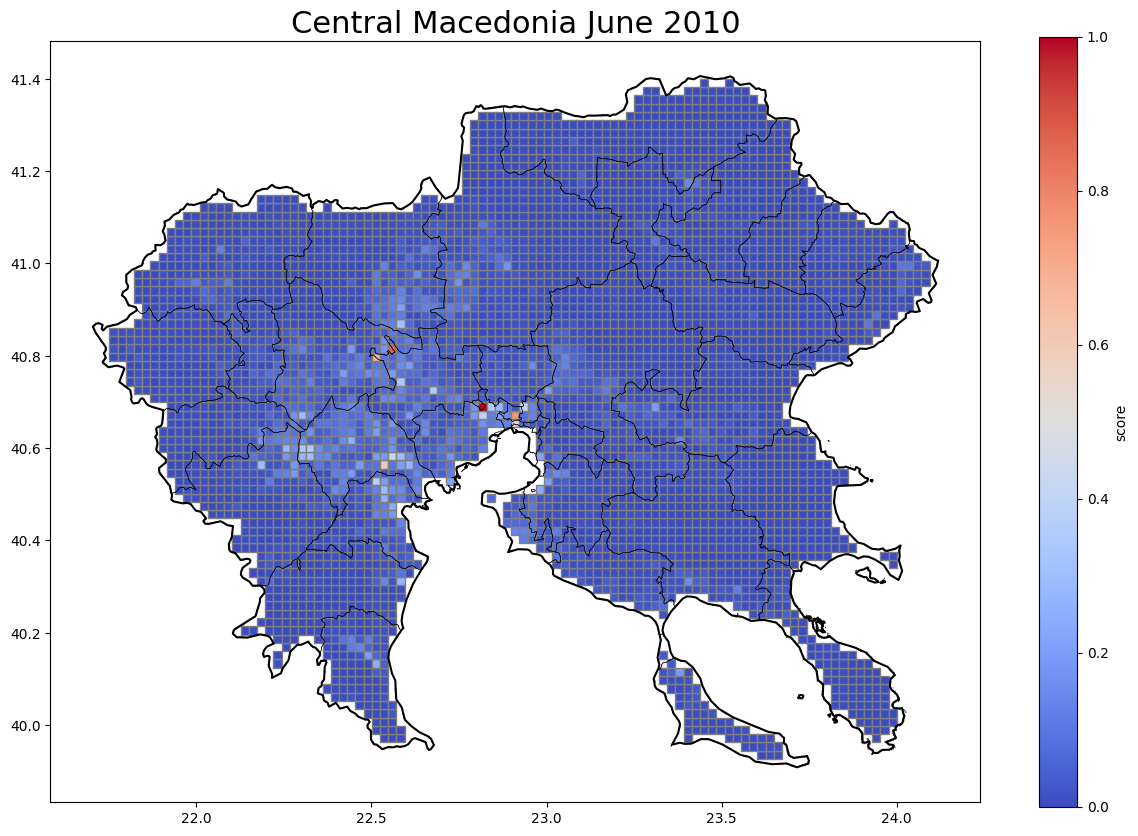

In [51]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title(f'Central Macedonia June {TEST_YEAR}', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

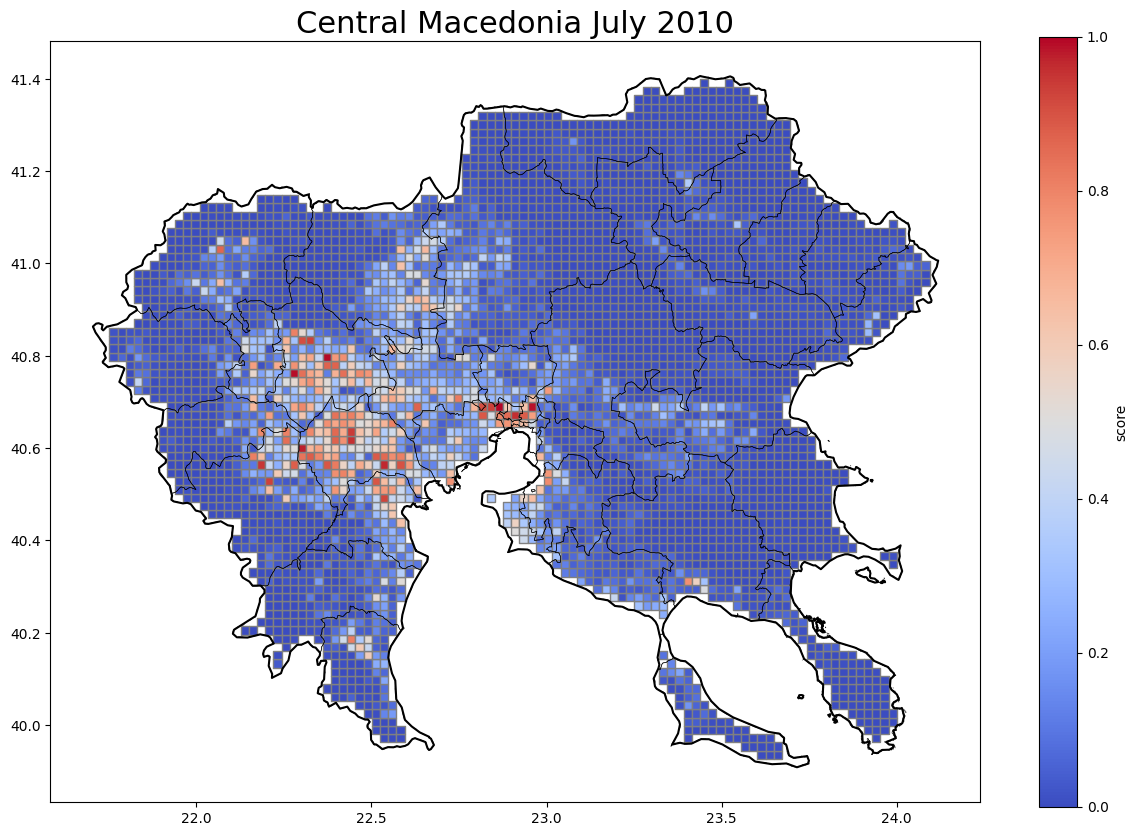

In [52]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title(f'Central Macedonia July {TEST_YEAR}', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

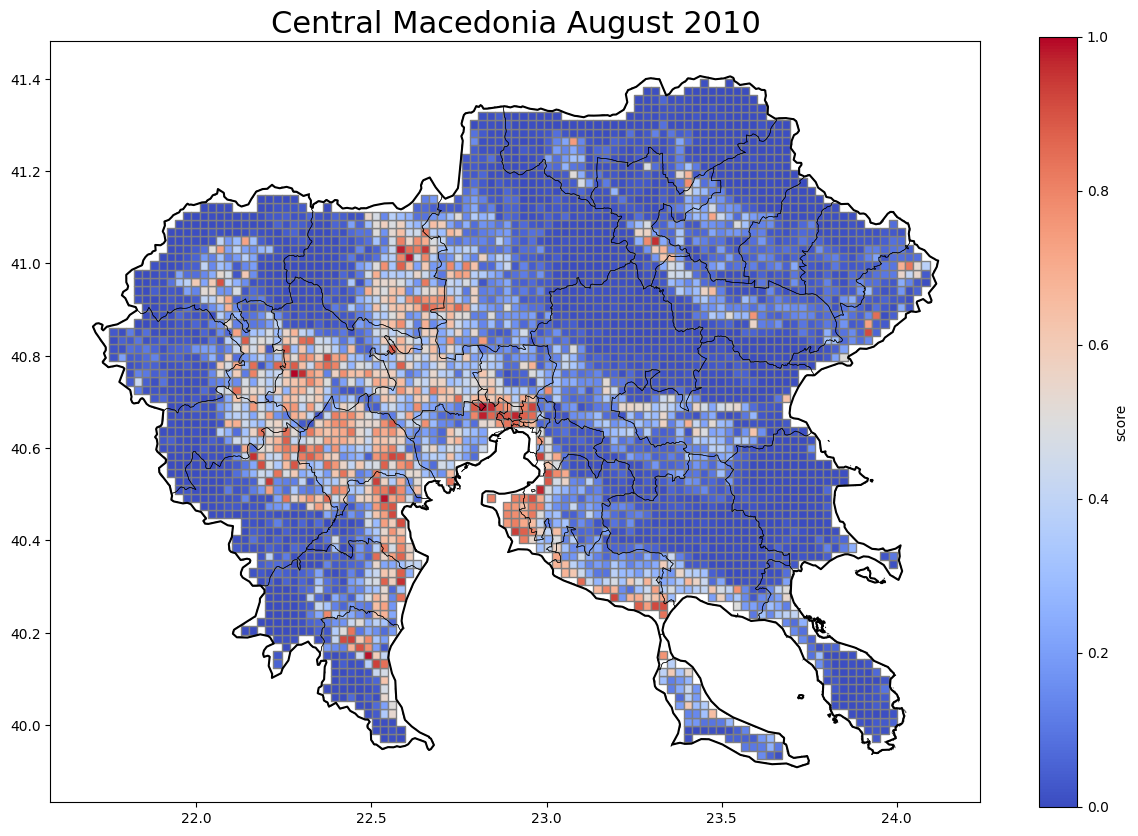

In [53]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title(f'Central Macedonia August {TEST_YEAR}', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

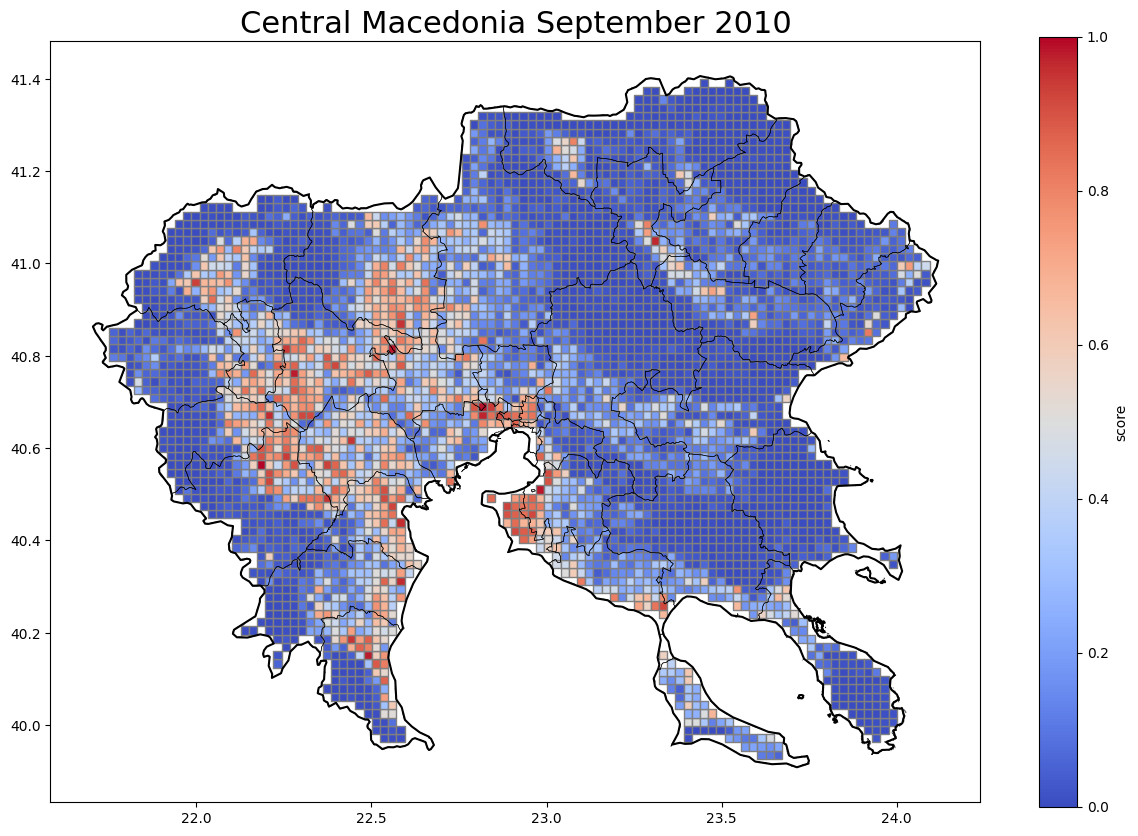

In [54]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title(f'Central Macedonia September {TEST_YEAR}', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

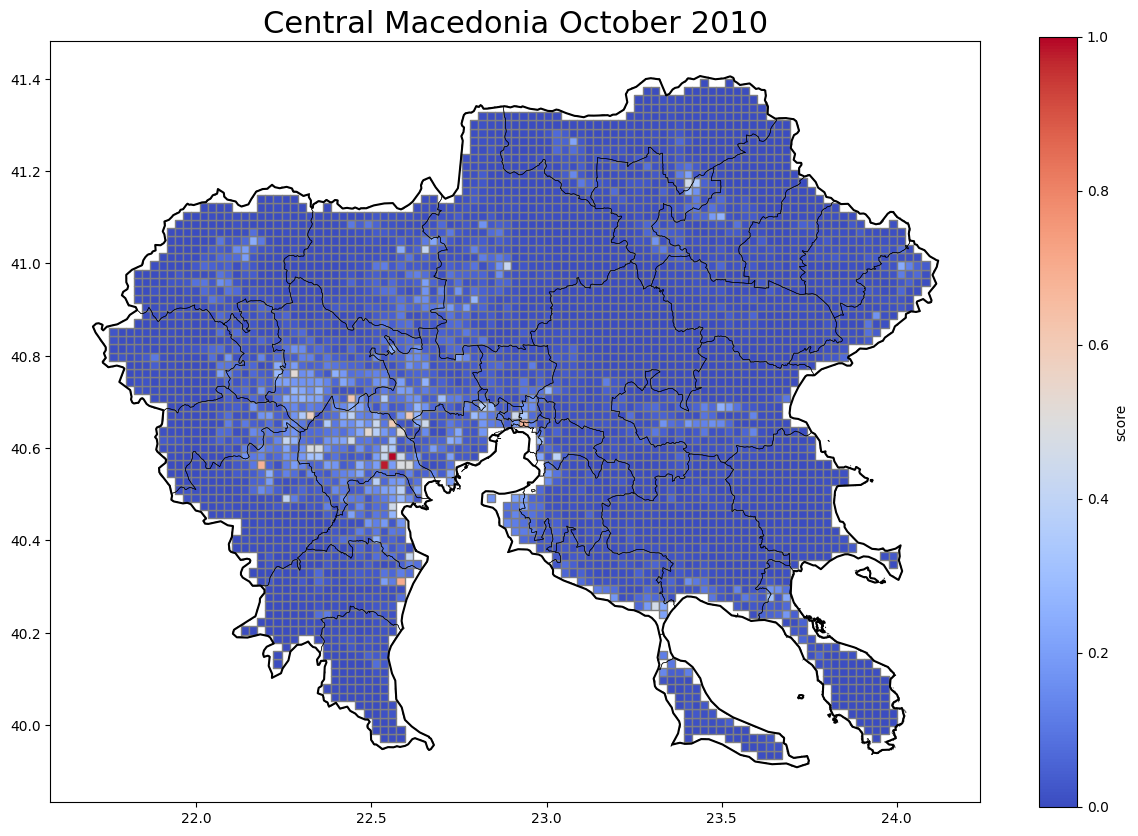

In [55]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title(f'Central Macedonia October {TEST_YEAR}', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()